# Testing Low Dimensional Affinities (Q values) computation methods

This notebook explores three methods to compute the joint probability distribution Q in the low-dimensional embedding space for the t-SNE algorithm. Each method balances precision and efficiency differently, catering to various dataset sizes and computational constraints.
Low dimentional affinities are defined as:
$$
\boxed{
\begin{array}{c}
q_{i,j} = \dfrac{k}{Z} \\
\\
\text {with simplified kernel} \quad k = \left(1 + \dfrac{d_{i,j}^2}{\alpha}\right)^{-\alpha}
\\
\\
\text{and} \quad Z = \sum_{k \ne \ell} \left(1 + \dfrac{d_{k,\ell}^2}{\alpha}\right)^{-\alpha}
\end{array}
}
$$

as in D Kobal et al, 2018


1. Barnes-Hut Approximation (calculate_sum_Q_BH)

Purpose: Computes the sum of Q using the Barnes-Hut (BH) approximation, a tree-based method that reduces the time complexity by approximating interactions for distant points.

**Key Steps:**

* Builds a quad-tree structure (QuadTree) over the low-dimensional embedding.
* Uses the tree to approximate the pairwise interactions efficiently, focusing detailed computations only on nearby points.
* Invokes a Cython-accelerated function (estimate_negative_gradient_bh) to compute the gradient and the Q-distribution.

**Advantages:**

* Efficient for moderately large datasets due to
$$ 
\mathcal{O}(n \log n)
$$

complexity.
* Reduces redundant computations for distant points by grouping them hierarchically.

**Drawbacks:**

* Performance depends on the theta parameter (trade-off between speed and accuracy).
* Overhead from tree construction and memory usage may be non-trivial for very large datasets.


2. Fast Fourier Transform Approximation (calculate_sum_Q_FFT)

**Purpose:** Computes the sum of Q using FFT-based approximation. This method exploits the convolutional properties of Fourier transforms to efficiently approximate pairwise interactions.

**Key Steps:**

* Uses interpolation and FFT to estimate the negative gradient and Q-distribution.
* Invokes another Cython-accelerated function (estimate_negative_gradient_fft_2d) to perform the FFT-based computation.

**Advantages:**

* Highly efficient for very large datasets, as FFT has low overhead compared to tree-building in Barnes-Hut.
* Scales well to high-dimensional embeddings or when n (number of points) is extremely large.

**Drawbacks:**

* Requires fine-tuning of interpolation parameters (e.g., n_interpolation_points, min_num_intervals).
* May introduce numerical inaccuracies for certain datasets due to approximation.

3. Exact Computation (KL_divergence_exact)

**Purpose:** Computes the exact value of the KL divergence loss for a given embedding by explicitly calculating pairwise distances and their contributions to Q.

**Key Steps:**

* Calculates Q directly using the squared distances and the t-SNE formulation.
* Normalizes Q and ensures numerical stability.
* Computes the KL divergence by comparing Q with the input affinities P.

**Advantages:**

* Exact and precise, providing the most accurate results without approximations.
* Straightforward implementation without additional hyperparameters.

**Drawbacks:**

Computationally expensive with 
$$
\mathcal{O}(n^2)
$$
complexity, making it infeasible for large datasets.

In [2]:
from sklearn.datasets import make_swiss_roll
import matplotlib.pyplot as plt
import seaborn as sns
import importlib # for reloading modules

from python_tsne_utils import utils


importlib.reload(utils)

<module 'python_tsne_utils.utils' from '/Users/a1/Documents/t-SNE-project/Optsne/python_tsne_utils/utils.py'>

In [ ]:
INITIAL_ALPHA = 1.0

#### Load dataset: 

In [15]:
# load toy data
X, _ = make_swiss_roll(n_samples=500, noise=0.2)

#### Initialize a test embedding

In [16]:
initial_embedding, P = utils.initialize_tsne_embedding(X=X, initial_alpha=INITIAL_ALPHA)
print("Done")

Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Done


#### Calculate sum_Q using different methods and compare

In [ ]:
importlib.reload(utils)
exact_Qs = []
bh_Qs = []
fft_Qs = []

for i in range(100):
    initial_embedding.optimize(1, inplace=True, dof=INITIAL_ALPHA)

    # custom implementation of the sum_Q calculation
    _, _, sum_Q_exact = utils.compute_low_dim_affinities_exact(
        Y=initial_embedding, α=INITIAL_ALPHA
    )
    exact_Qs.append(sum_Q_exact)

    # calculate sum_Q using Barnes-Hut from the openTSNE library
    sum_Q_bh = utils.calculate_sum_Q_BH(embedding=initial_embedding, α=INITIAL_ALPHA)
    bh_Qs.append(sum_Q_bh)

    # calculate sum_Q using FFT from the openTSNE library
    sum_Q_fft = utils.calculate_sum_Q_FFT(embedding=initial_embedding, α=INITIAL_ALPHA)
    fft_Qs.append(sum_Q_fft)

    print(f"sum_Q_exact: {sum_Q_exact}, sum_Q_bh: {sum_Q_bh}, sum_Q_fft: {sum_Q_fft}")

sum_Q_exact: 5437.3310546875, sum_Q_bh: 5404.3721103211765, sum_Q_fft: 5446.584043999045
sum_Q_exact: 5405.3330078125, sum_Q_bh: 5373.469176252792, sum_Q_fft: 5414.027102795785
sum_Q_exact: 5377.26123046875, sum_Q_bh: 5345.672943622806, sum_Q_fft: 5386.752209623416
sum_Q_exact: 5350.8125, sum_Q_bh: 5318.892798689207, sum_Q_fft: 5359.2033239989205
sum_Q_exact: 5324.64306640625, sum_Q_bh: 5293.268491733979, sum_Q_fft: 5333.6153442046125
sum_Q_exact: 5298.45556640625, sum_Q_bh: 5267.23375405369, sum_Q_fft: 5305.691494225086
sum_Q_exact: 5273.5625, sum_Q_bh: 5242.144047615169, sum_Q_fft: 5282.157828114007
sum_Q_exact: 5251.48583984375, sum_Q_bh: 5220.368733827401, sum_Q_fft: 5259.205793727191
sum_Q_exact: 5231.67529296875, sum_Q_bh: 5200.088950902635, sum_Q_fft: 5239.378366593561
sum_Q_exact: 5213.6474609375, sum_Q_bh: 5182.468313361381, sum_Q_fft: 5221.550319789086
sum_Q_exact: 5194.59033203125, sum_Q_bh: 5163.646734922696, sum_Q_fft: 5203.527900868852
sum_Q_exact: 5173.47509765625, sum_Q

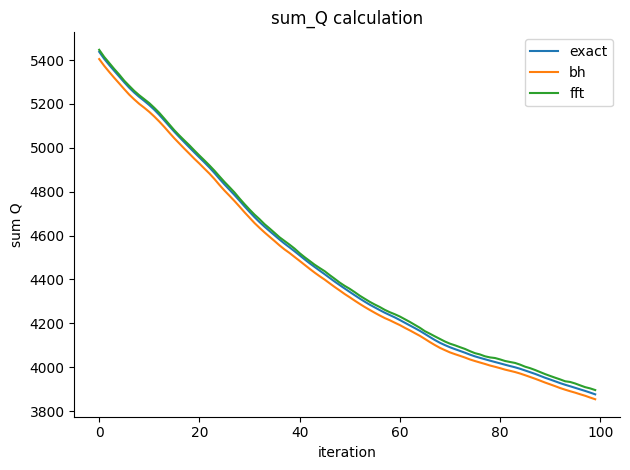

In [27]:
plt.plot(exact_Qs, label="exact")
plt.plot(bh_Qs, label="bh")
plt.plot(fft_Qs, label="fft")
plt.xlabel("iteration")
plt.ylabel("sum Q")
plt.title("sum_Q calculation")
plt.legend()
plt.tight_layout()
sns.despine()
plt.show()